# County Obesity Hotspot Analysis Workflow (Multi data Download)

This notebook demonstrates a clean multi-agent GAS workflow for a real public-health use case:

**Where are the statistically significant clusters (hot spots and cold spots) of adult obesity prevalence across U.S. counties?**


## Install GAS Client SDK


In [1]:
%pip install -q gas-client

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
import os
from pathlib import Path
from urllib.parse import urljoin

from dotenv import load_dotenv
from IPython.display import HTML, Image, display

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

from gas_client import GasClient


## User Settings


In [3]:
load_dotenv(project_root / ".env")

server_url = os.getenv("GAS_SERVER_URL", "http://127.0.0.1:4042")

openai_api_key = os.getenv("OPENAI_API_KEY")
if not openai_api_key:
    raise RuntimeError("Set OPENAI_API_KEY in the repo .env file before running this notebook.")

timeout_seconds = 1800

client = GasClient(
    server_url,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
    artifact_delivery="URL",
)

credentials = {"OPENAI_API_KEY": openai_api_key}


## Bind to the Five Agents

In [4]:
data_agent = client.agent("geospatial_data_retrieval_agent")
vector_agent = client.agent("vector_analysis_agent")
projection_agent = client.agent("map_projection_agent")
stats_agent = client.agent("spatial_statistics_agent")
mapping_agent = client.agent("mapping_agent")

for agent in [data_agent, vector_agent, projection_agent, stats_agent, mapping_agent]:
    print(agent.agent_id, agent.status().get("status"))

geospatial_data_retrieval_agent available
vector_analysis_agent available
map_projection_agent available
spatial_statistics_agent available
mapping_agent available


## Helper Functions


In [ ]:
# Artifact handling uses the GAS Client SDK helpers directly.
# Use client.get_artifacts(...), client.get_artifact_urls(...),
# client.print_artifacts(...), and client.display_artifacts(...).


## Step 1: Multi-Download (Counties + CDC Obesity Prevalence)


In [5]:
multi_retrieval_result = data_agent.run_streaming_task((
        "Please download two datasets for the contiguous United States:\n"
        "1) Use the U.S. Census Bureau TIGER boundary source. Download 2020 county polygons "
        "for the contiguous United States. Exclude Alaska, Hawaii, Puerto Rico, and other "
        "territories. Return one clean GeoPackage with county geometry, GEOID, county name, "
        "state name or abbreviation, STATEFP, and COUNTYFP fields.\n"
        "2) Use the CDC PLACES data source. Download 2020 county-level crude prevalence of "
        "adult obesity for the contiguous United States. Return one clean dataset with county "
        "GEOID/FIPS, county name, state identifier, year, measure name, and the obesity "
        "prevalence value as a numeric column. Geometry is not required for this dataset.\n\n"
    ),
)

# # Collect every artifact URL the multi-download produced, in sub-request order.
# downloaded_urls = [
#     a["url"]
#     for a in (multi_retrieval_result.get("outputs", {}).get("artifacts", []) or [])
#     if a.get("url")
# ]

# if len(downloaded_urls) < 2:
#     raise RuntimeError(
#         f"Expected 2 downloaded artifacts (counties, obesity) but got {len(downloaded_urls)}. "
#         "Inspect the multi-retrieval task output above before proceeding.\n"
#         f"Artifacts: {downloaded_urls}"
#     )

# # Position-based assignment matches the order in the multi-download prompt.
# county_boundary_url, obesity_url = downloaded_urls[0], downloaded_urls[1]

# print("counties:", county_boundary_url)
# print("obesity :", obesity_url)

# sub_tasks = multi_retrieval_result.get("outputs", {}).get("sub_tasks", []) or []
# if sub_tasks:
#     print("\nSub-task breakdown (verify the request-to-artifact mapping):")
#     for record in sub_tasks:
#         req_preview = (record.get("sub_request") or "")[:90]
#         print(
#             f"  #{record.get('sub_request_index')} "
#             f"({record.get('artifact_count')} artifact(s)): "
#             f"{req_preview}..."
#         )

[11:53:07] stream_connected: Streaming connection established.
[11:53:07] Geospatial Data Retrieval Agent: I received your request.
[11:53:07] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[11:53:07] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[11:53:08] task_accepted: Task accepted. Starting streaming execution.
[11:53:08] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[11:53:08] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[11:53:10] Geospatial Data Retrieval Agent: The request was decomposed into 2 sub-request(s).
[11:53:10] Geospatial Data Retrieval Agent: I detected 2 datasets in your request. I will download each one as a separate sub-task and return all artifacts.
[11:53:10] Geospatial Data Retrieval Agent:

Artifacts: 2
1. Dataset
   role             : dataset_paths
   format           : gpkg
   type             : downloadable_file
   name             : geospatial_data_retrieval_agent-6601-vvyc-7083.gpkg
   original_filename: download_2020_560671.gpkg
   size_bytes       : 18223104
   url              : http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-6601-vvyc-7083.gpkg
2. Dataset
   role             : dataset_paths
   format           : csv
   type             : downloadable_file
   name             : geospatial_data_retrieval_agent-2620-duji-6646.csv
   original_filename: download_2020_233490.csv
   size_bytes       : 113316
   url              : http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-2620-duji-6646.csv


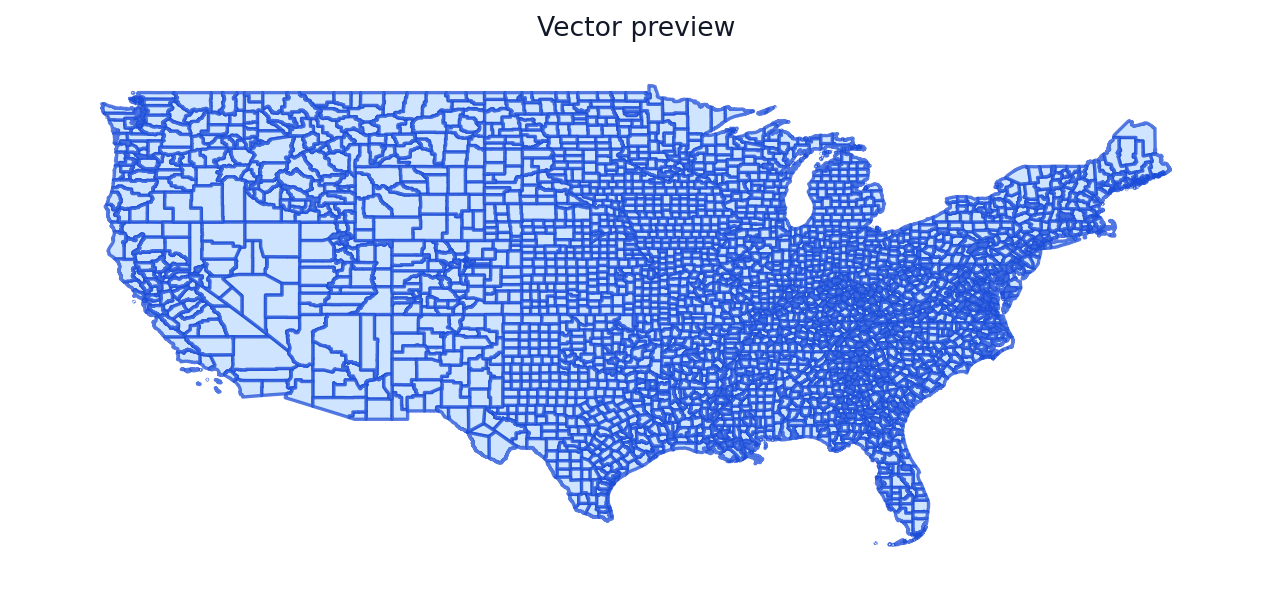

GEOID,NAME,STATEFP,COUNTYFP
13031,Bulloch,13,031
13121,Fulton,13,121
13179,Liberty,13,179
13189,McDuffie,13,189
13213,Murray,13,213


countyfips,countyname,state,year,measureid,data_value
01001,Autauga,AL,2020,OBESITY,37.6
01003,Baldwin,AL,2020,OBESITY,32.9
01005,Barbour,AL,2020,OBESITY,46.1
01007,Bibb,AL,2020,OBESITY,38.6
01009,Blount,AL,2020,OBESITY,32.9


In [7]:
client.print_artifacts(multi_retrieval_result)
client.display_artifacts(multi_retrieval_result)

In [8]:
county_boundary_url = client.get_artifact_urls(multi_retrieval_result)[0]
obesity_url = client.get_artifact_urls(multi_retrieval_result)[1]
print("County boundary URL:", county_boundary_url)
print("Obesity URL:", obesity_url)

County boundary URL: http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-6601-vvyc-7083.gpkg
Obesity URL: http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-2620-duji-6646.csv


## Step 2: Join Boundaries With Obesity Prevalence

In [17]:
join_result = vector_agent.run_streaming_task((
        "Join the contiguous US county boundary dataset with the 2020 CDC PLACES county-level adult "
        "obesity prevalence dataset. Name joined obesity value column to obesity_rate."
        "Return GeoPackage ready for spatial statistics."
    ),
    input_datasets=[county_boundary_url, obesity_url],
)


[12:07:20] stream_connected: Streaming connection established.
[12:07:21] Vector Analysis Agent: I received your request.
[12:07:21] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 2 dataset reference(s).
[12:07:21] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[12:07:21] task_accepted: Task accepted. Starting streaming execution.
[12:07:21] Vector Analysis Agent: Next I will start the workflow with the prepared inputs.
[12:07:22] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 2 dataset reference(s).
[12:07:22] Vector Analysis Agent: I detected a common vector operation and will first try a deterministic GeoPandas workflow.
[12:07:22] Vector Analysis Agent: Joined 3108 spatial features with 3144 table/vector records using GEOID = countyfips. Matched 3108 output feature

http://127.0.0.1:4042/agents/vector_analysis_agent/data/vector_analysis_agent-5077-wdee-3111.gpkg


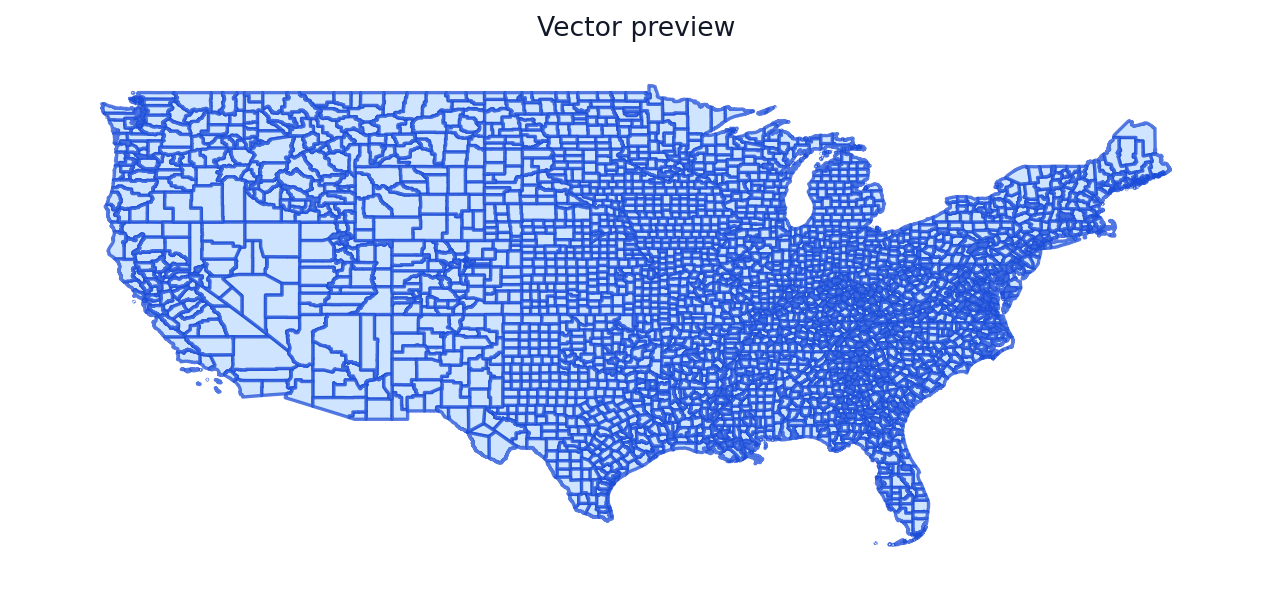

GEOID,NAME,STATEFP,COUNTYFP,countyfips,countyname,state,year,measureid,obesity_rate
13031,Bulloch,13,031,13031,Bulloch,GA,2020,OBESITY,35.1
13121,Fulton,13,121,13121,Fulton,GA,2020,OBESITY,29.3
13179,Liberty,13,179,13179,Liberty,GA,2020,OBESITY,40.0
13189,McDuffie,13,189,13189,McDuffie,GA,2020,OBESITY,41.6
13213,Murray,13,213,13213,Murray,GA,2020,OBESITY,37.7


In [18]:
county_obesity_url = client.get_artifact_urls(join_result)[0]
print(county_obesity_url)    

client.display_artifacts(join_result)

## Step 3: Reproject to EPSG:5070 (Conus Albers)


In [23]:
projection_result = projection_agent.run_streaming_task((
        "Reproject the input county dataset to Conus Albers Equal Area."
    ),
    input_datasets=[county_obesity_url],
)

[12:10:16] stream_connected: Streaming connection established.
[12:10:17] Map Projection Agent: I received your request.
[12:10:17] Map Projection Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[12:10:17] Map Projection Agent: I found the required credentials and can start the model-backed workflow.
[12:10:17] task_accepted: Task accepted. Starting streaming execution.
[12:10:17] Map Projection Agent: Next I will start the workflow with the prepared inputs.
[12:10:17] Map Projection Agent: I will inspect 1 dataset reference(s), identify their current CRS, and choose an appropriate target projection for the request.
[12:10:17] Map Projection Agent: I am loading an input dataset so I can inspect its current coordinate reference system.
[12:10:17] Map Projection Agent: I am selecting a target CRS from the request text and dataset extent using local pyproj/geopandas logic.
[12:10:17] Map Projection Age

In [30]:
county_obesity_projected_url = client.get_artifact_urls(projection_result)[0]
print(county_obesity_projected_url)

http://127.0.0.1:4042/agents/map_projection_agent/data/map_projection_agent-0526-gepi-4064.gpkg


## Step 4: Local Moran's I (LISA) Cluster Analysis


In [31]:
lisa_result = stats_agent.run_streaming_task((
        "Perform an Exploratory Spatial Data Analysis on the input county dataset. "
        "Target variable: obesity_rate. "
        "1) Build Queen-contiguity spatial weights and row-standardize them. "
        "2) Compute the Global Moran's I statistic with 999 permutations and report the I value, "
        "expected I, z-score, and pseudo p-value. "
        "3) Compute Local Moran's I (LISA) with 999 permutations and classify each county into "
        "'High-High', 'Low-Low', 'High-Low', 'Low-High', or 'Not Significant' at p < 0.05. "
        "4) Return a polished HTML report with the Moran scatterplot, a LISA significance map, and "
        "a LISA cluster map embedded. "
        "5) **REQUIRED**: also return a GeoPackage (.gpkg) primary artifact containing the input "
        "county polygons augmented with the new fields 'local_I', 'local_p_value', and "
        "'lisa_cluster' (the categorical label). This GeoPackage is required for the next mapping "
        "step. "
        "Interpret the results in the report in plain English suitable for a public-health audience."
    ),
    input_datasets=[county_obesity_projected_url],
)

[12:14:36] stream_connected: Streaming connection established.
[12:14:36] Spatial Statistics Agent: I received your request.
[12:14:36] Spatial Statistics Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[12:14:36] Spatial Statistics Agent: I found the required credentials and can start the model-backed workflow.
[12:14:36] task_accepted: Task accepted. Starting streaming execution.
[12:14:37] Spatial Statistics Agent: Next I will start the workflow with the prepared inputs.
[12:14:37] Spatial Statistics Agent: I will inspect the datasets, choose suitable PySAL methods, generate analysis code, and return a modeling report.
[12:14:37] Spatial Statistics Agent: I am inspecting the input datasets to identify geometry types, CRS, numeric fields, candidate modeling variables, and usable PySAL workflows.
[12:14:37] Spatial Statistics Agent: Dataset inspection is complete. I identified candidate variables, 

In [34]:
client.print_artifacts(lisa_result)

Artifacts: 5
1. Text Report
   role             : text_report_file
   format           : txt
   type             : downloadable_file
   name             : spatial_statistics_agent-4964-vrfw-0408.txt
   original_filename: perform_an_494777.txt
   size_bytes       : 3908
   url              : http://127.0.0.1:4042/agents/spatial_statistics_agent/data/spatial_statistics_agent-4964-vrfw-0408.txt
2. Html Report
   role             : html_report_file
   format           : html
   type             : downloadable_file
   name             : spatial_statistics_agent-4093-czkf-8136.html
   original_filename: perform_an_708382.html
   size_bytes       : 8606
   url              : http://127.0.0.1:4042/agents/spatial_statistics_agent/data/spatial_statistics_agent-4093-czkf-8136.html
3. Media Artifact
   role             : media_artifact_files
   format           : png
   type             : downloadable_file
   name             : spatial_statistics_agent-2721-uctf-4571.png
   original_filename: lisa

### View the Statistical Report


In [36]:
client.display_artifacts(lisa_result, format="html")

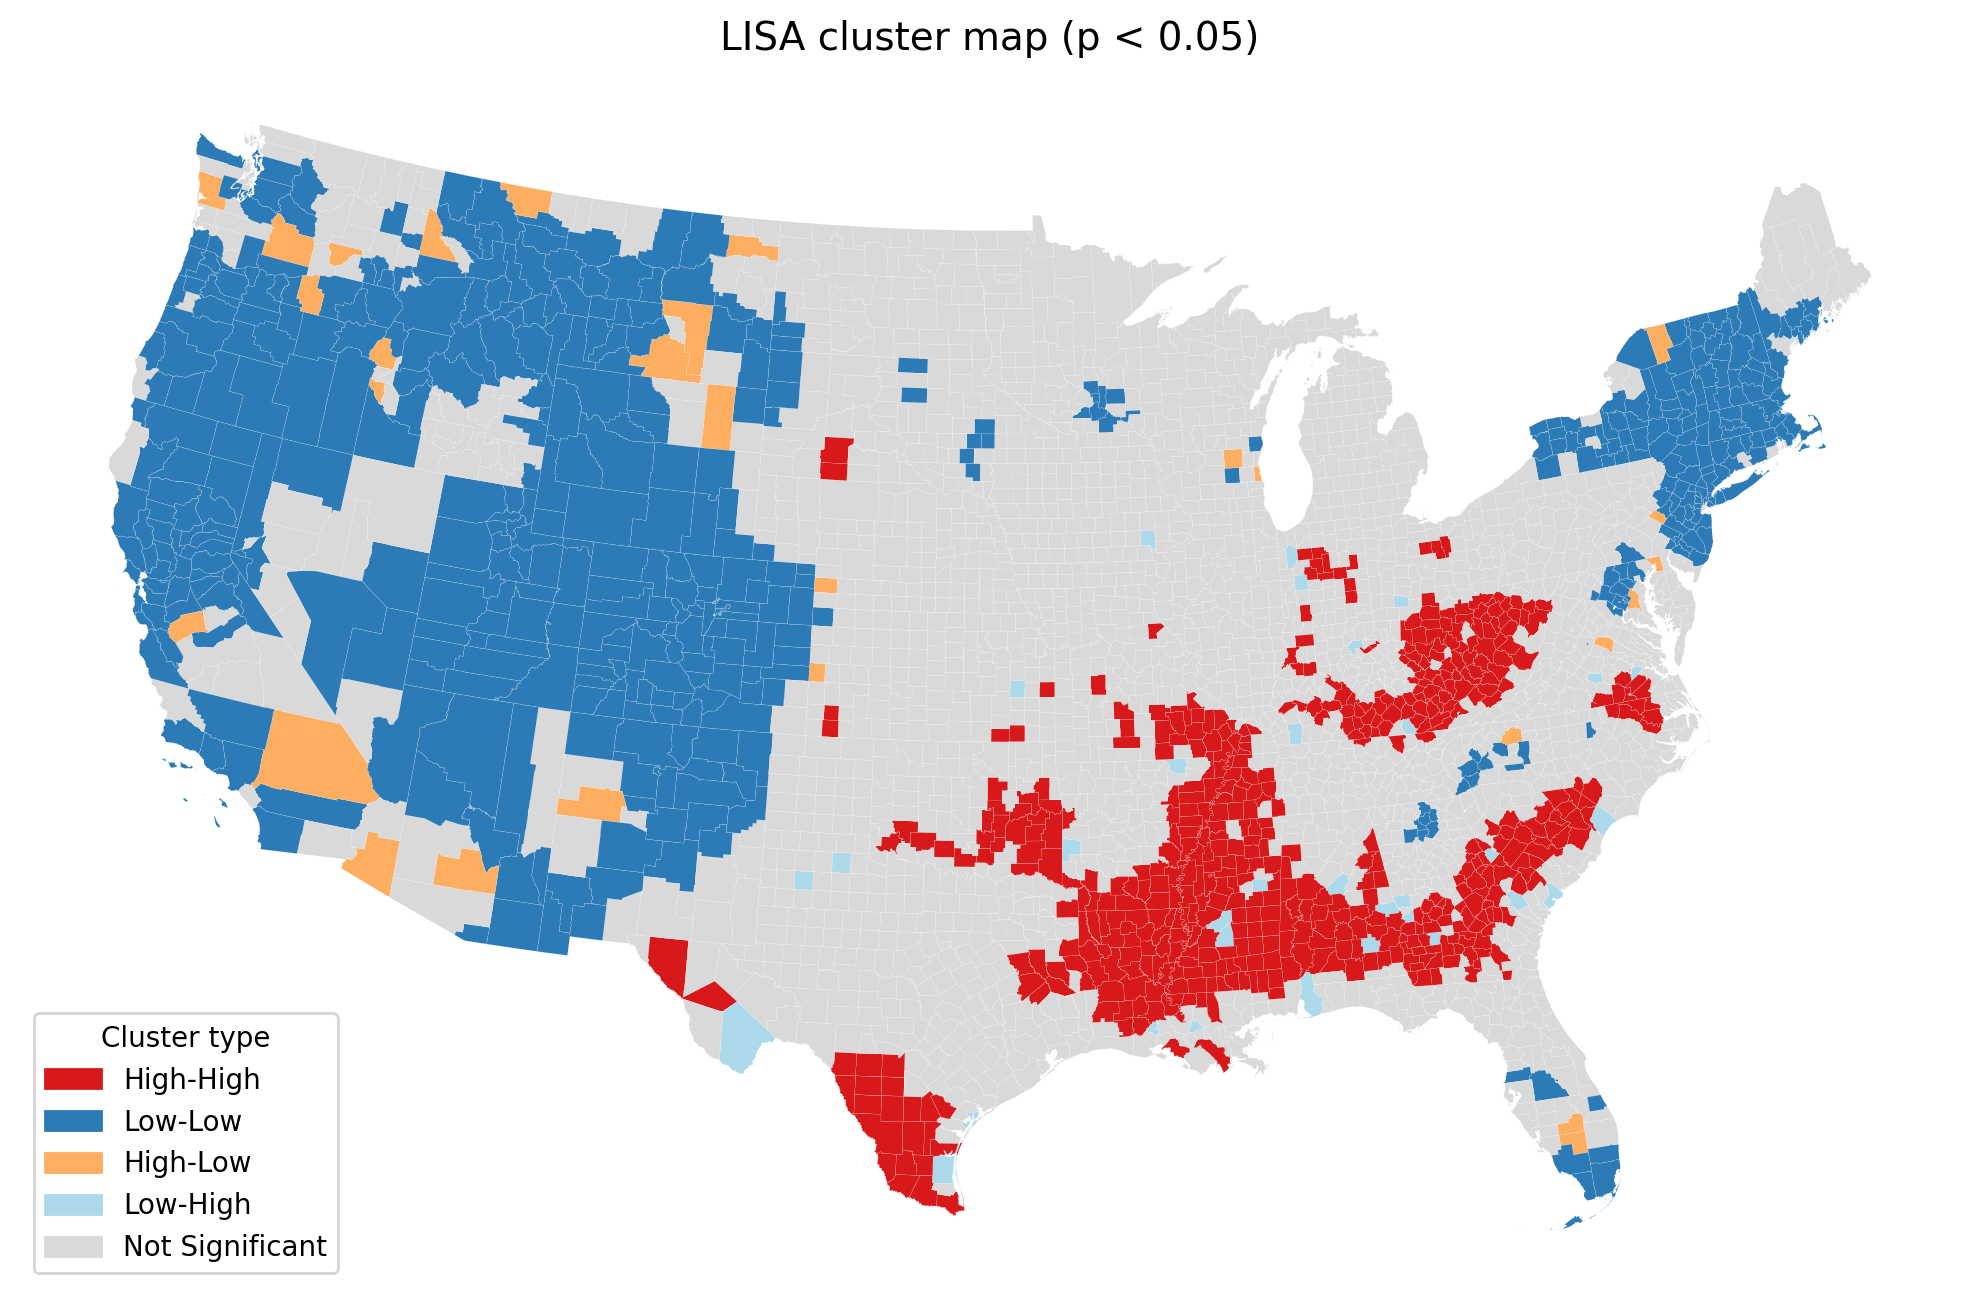

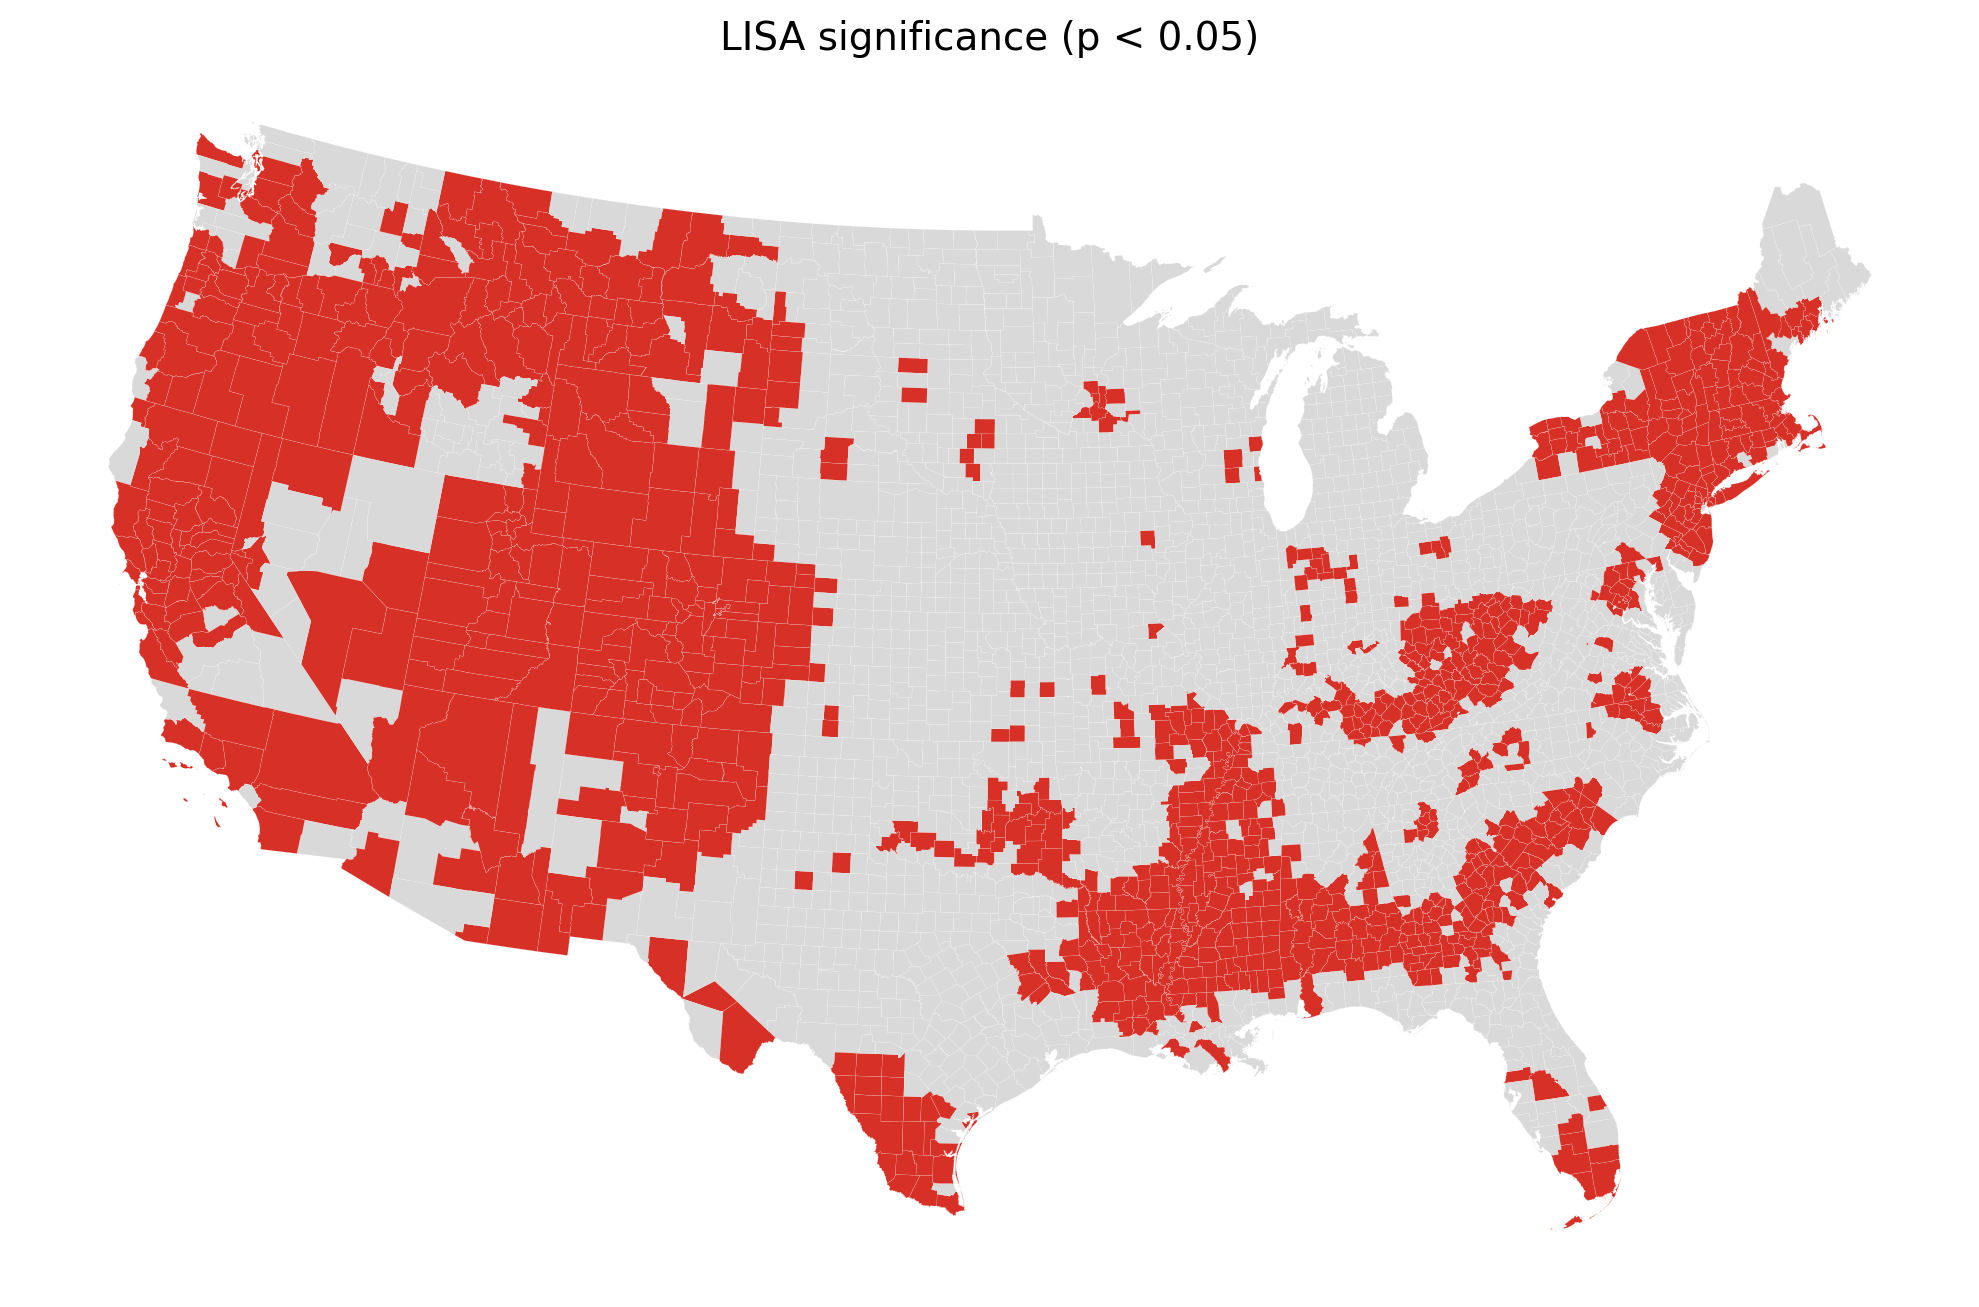

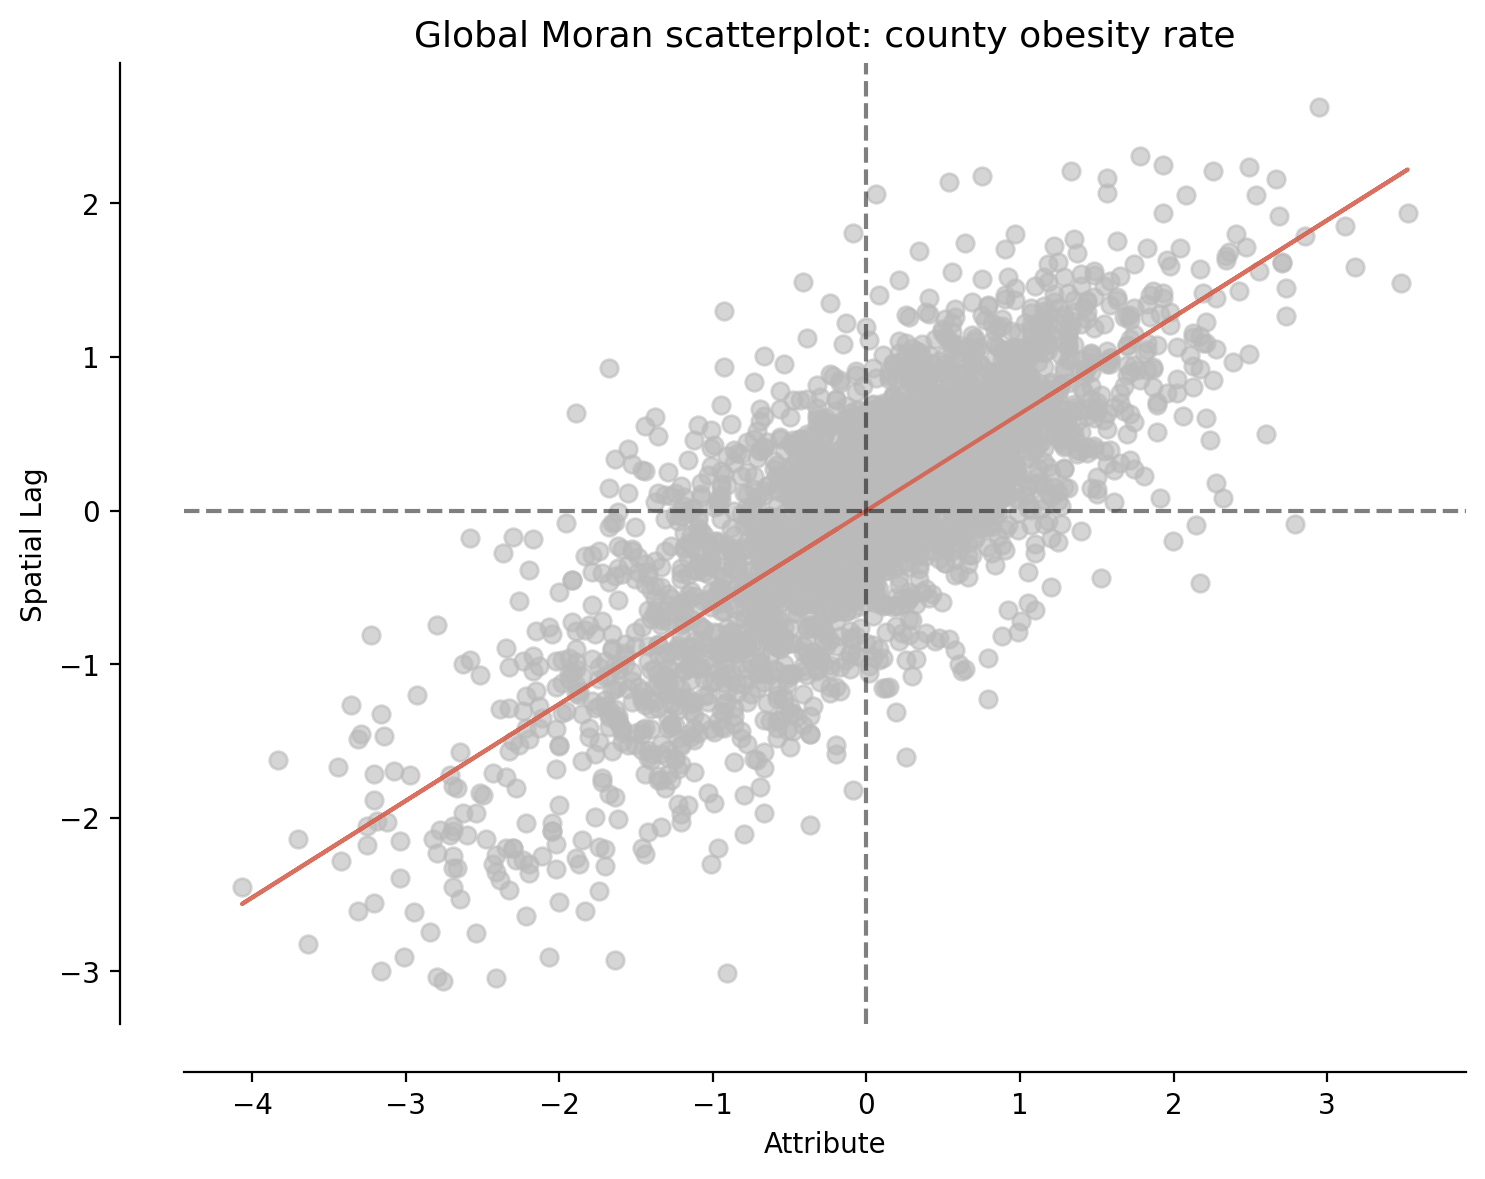

In [37]:
client.display_artifacts(lisa_result, format="png")